<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/01_GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Global state and environment-conditioned decomposition

The global state of a multibody system can be written as when focusing on a subsystem $S_a$.

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{L_S}\sum_{j=1}^{L_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

We consider a three-qubit state with one subsystem qubit $S$ and two environment qubits $E$
$$
|\Psi_{SE}\rangle =
\frac{1}{\sqrt{8}}
\left(|000\rangle+|001\rangle+|010\rangle+|011\rangle
+|100\rangle+|101\rangle+|110\rangle-|111\rangle\right).
$$

Taking the first qubit as system $S_0$ and the last two as environment $E$. The environment basis is $\{|e_j⟩\}_{j=1}^{4} = \{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}.$ The environment conditioned decomposition is:
$$
|\Psi_{SE}\rangle
=
\frac{1}{\sqrt{8}}((|0\rangle+|1\rangle)|00\rangle
+(|0\rangle+|1\rangle)|01\rangle
+(|0\rangle+|1\rangle)|10\rangle
+(|0\rangle-|1\rangle)|11\rangle) ,
$$

Further simplified as:

$$
|\Psi_{SE}\rangle
=
\frac{1}{2}|\chi_1^{S_0}\rangle|00\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|01\rangle
+\frac{1}{2}|\chi_1^{S_0}\rangle|10\rangle
+\frac{1}{2}|\chi_2^{S_0}\rangle|11\rangle ,
$$

where

$$
|\chi_1^{S_0}\rangle=\frac{|0\rangle+|1\rangle}{\sqrt{2}},
\qquad
|\chi_1^{S_0}\rangle=\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$

Thus each environment outcome has probability

$$
\lambda_j^E=\frac{1}{4}.
$$

### 2. Local state: density matrix

The reduced state of the subsystem is obtained by tracing out the environment:

$$
\rho_{S_0} =
\sum_{j=1}^{4}\lambda_j^E
|\chi_j^{S_0}\rangle\langle \chi_j^{S_0}|.
$$

For this example,

$$
\rho_{S_0}
=
\frac{3}{4}|\chi_1^{S_0}\rangle\langle \chi_1^{S_0}|
+\frac{1}{4}|\chi_2^{S_0}\rangle\langle \chi_2^{S_0}|.
$$

In the computational basis,

$$
\rho_{S_0} =
\begin{pmatrix}
1/2 & 1/4 \\
1/4 & 1/2
\end{pmatrix}.
$$

This is a mixed local state, even though the full three-qubit state is pure.

### 3. Local state: geometric quantum state

The same local state can be represented as a probability measure over pure subsystem states:

$$
Q^{S_0} =
\sum_{j=1}^{4}
\lambda_j^E
\delta_{|\chi_j^{S_0}\rangle}.
$$

Since three environment outcomes give $|\chi_1^{S_0}\rangle$ and one gives $|\chi_2^{S_0}\rangle $,

$$
Q^{S_0} =
\frac{3}{4}\delta_{|\chi_1^{S_0}\rangle}
+\frac{1}{4}\delta_{|\chi_2^{S_0}\rangle}.
$$

Thus the geometric quantum state keeps track of the pure states appearing in the environment-conditioned ensemble, together with their probabilities.

In [1]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site

In [6]:
from gqs import*
from gqs.distances import Psi_Dist, _mask_chi_lambda

In [25]:
def random_wavefunction(num_qubits, seed=None):
    """
    Return a normalized random wavefunction for `num_qubits`.

    The state lives in a Hilbert space of dimension 2**num_qubits:
        |Psi_SE> = sum_i psi_i |i>

    Parameters
    ----------
    num_qubits : int
        Total number of qubits in S + E.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    psi : np.ndarray
        Complex normalized wavefunction of shape (2**num_qubits,).
    """
    rng = np.random.default_rng(seed)

    dim = 2**num_qubits

    # Random complex amplitudes
    psi = rng.normal(size=dim) + 1j * rng.normal(size=dim)

    # Normalize
    psi = psi / np.linalg.norm(psi)

    return psi

def print_wavefunction(psi, tol=1e-12, ncols=4):
    """
    Print wavefunction in computational basis using multiple columns,
    with '+' signs between terms.
    """
    dim = len(psi)
    num_qubits = int(np.log2(dim))

    entries = []

    for i, amp in enumerate(psi):
        if abs(amp) > tol:
            basis = format(i, f"0{num_qubits}b")
            entries.append(f"({amp:.4f}) |{basis}>")

    for i in range(0, len(entries), ncols):
        row = entries[i:i+ncols]

        # Add + between entries in the same row
        line = " + ".join(f"{entry:<28}" for entry in row)

        # Add + at the end of the row if more entries remain
        if i + ncols < len(entries):
            line += " +"

        print(line)

def print_density_matrix(rho, basis_labels=None, precision=4, title=r"rho_S"):
    """
    Print a density matrix nicely with optional basis labels.

    Parameters
    ----------
    rho : np.ndarray
        Density matrix.
    basis_labels : list of str or None
        Basis labels, e.g. ["|0>", "|1>"].
    precision : int
        Number of digits to print.
    title : str
        Name/title for the matrix.
    """
    rho = np.asarray(rho)

    d = rho.shape[0]

    if basis_labels is None:
        basis_labels = [f"|{i}>" for i in range(d)]

    print(f"{title} =")
    print()

    # Header row
    header = " " * 10
    for label in basis_labels:
        header += f"{label:^18}"
    print(header)

    # Matrix rows
    for i in range(d):
        row = f"{basis_labels[i]:<10}"
        for j in range(d):
            row += f"{format_complex(rho[i, j], precision):^18}"
        print(row)

    print()
    print(f"Trace = {np.trace(rho).real:.{precision}f}")
    print(f"Hermitian check = {np.allclose(rho, rho.conj().T)}")


def format_complex(z, precision=4, chop=1e-12):
    """
    Nicely format a complex number.
    """
    z = complex(z)

    real = 0.0 if abs(z.real) < chop else z.real
    imag = 0.0 if abs(z.imag) < chop else z.imag

    if imag == 0:
        return f"{real:.{precision}f}"
    elif real == 0:
        return f"{imag:.{precision}f}j"
    elif imag > 0:
        return f"{real:.{precision}f}+{imag:.{precision}f}j"
    else:
        return f"{real:.{precision}f}{imag:.{precision}f}j"


def gqs_single_site_table(
    chi_S,
    lambda_E,
    d_hilbert=2,
    n_chain=None,
    precision=4,
    tol=1e-12,
):
    """
    Return the single-site GQS as a pandas DataFrame.

    Columns:
        1. j
        2. environment state
        3. |chi_j^S>
        4. lambda_E[j]
    """
    chi_S = np.asarray(chi_S)
    lambda_E = np.asarray(lambda_E)

    d_E, d_S = chi_S.shape

    if n_chain is not None:
        n_env = n_chain - 1
    else:
        n_env = int(np.round(np.log(d_E) / np.log(d_hilbert)))

    rows = []

    for j in range(d_E):
        lam = lambda_E[j]

        if lam <= tol:
            continue

        # Environment basis label
        if d_hilbert == 2:
            env_label = f"|{format(j, f'0{n_env}b')}>"
        else:
            env_label = f"|e_{j}>"

        # Conditional subsystem state
        terms = []
        for k in range(d_S):
            amp = chi_S[j, k]

            if abs(amp) > tol:
                amp_str = format_complex(amp, precision=precision)
                terms.append(f"({amp_str}) |{k}>")

        chi_str = " + ".join(terms)

        rows.append(
            {
                "j": j,
                "Environment state": env_label,
                r"|χ_j^S⟩": chi_str,
                r"λ_E[j]": np.round(lam, precision),
            }
        )

    return pd.DataFrame(rows)


def print_gqs_single_site(
    chi_S,
    lambda_E,
    d_hilbert=2,
    n_chain=None,
    system_site=None,
    precision=4,
    tol=1e-12,
    title="Geometric Quantum State Q^S"
):
    """
    Print the environment-conditioned GQS ensemble nicely.

    Parameters
    ----------
    chi_S : np.ndarray
        Conditional subsystem states, shape (d_E, d_hilbert).
        Row j is |chi_j^S>.
    lambda_E : np.ndarray
        Environment probabilities, shape (d_E,).
    d_hilbert : int
        Local Hilbert space dimension.
    n_chain : int or None
        Total number of sites. Used only for labeling environment states.
    system_site : int or None
        Chosen subsystem site. Used only for printing context.
    precision : int
        Number of digits to print.
    tol : float
        Threshold for skipping zero-probability environment outcomes.
    title : str
        Title for printed output.
    """
    chi_S = np.asarray(chi_S)
    lambda_E = np.asarray(lambda_E)

    d_E, d_S = chi_S.shape

    if n_chain is not None:
        n_env = n_chain - 1
    else:
        n_env = int(np.log(d_E) / np.log(d_hilbert))

    print(title)
    print("=" * len(title))

    if system_site is not None:
        print(f"Subsystem site: {system_site}")
    print(f"Subsystem dimension d_S = {d_S}")
    print(f"Number of environment outcomes d_E = {d_E}")
    print()

    df_gqs = gqs_single_site_table(
    chi_S,
    lambda_E,
    d_hilbert=2,
    n_chain=3,
    precision=3
    )

    styles = [
        {'selector': 'td, th', 'props': [('border-right', '1px solid #ddd')]}
    ]
    df_gqs.style.set_table_styles(styles)
    display(add_column_borders(df_gqs))
    return


In [23]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
# ---------------------------------------------------
# Standalone colorbar colormaps
# ---------------------------------------------------
colors_sky_blue = ["#aed8f2", "#4a90e2", "#2467AA", "#023360"]
cmap_sky_blue = LinearSegmentedColormap.from_list("sky_to_blue", colors_sky_blue)

colors_warm_red = ["#ffb3b3", "#ff4d4d", "#b30000", "#5a0000"]
cmap_warm_red = LinearSegmentedColormap.from_list("warm_to_red", colors_warm_red)

def plot_density_matrix_from_gqs(
    states,
    weights=None,
    ax=None,
    title="Density matrix",
    show_bottom_text=False,
    bottom_text="Ensembles of particles\nAny length vectors",
    rhoS_label=None,
    rhoS_label_pos=(0.5, -0.1,0),
    arrow_color="#756ef9",
    sphere_alpha=0.10,
    elev=20,
    azim=-35
):
    """
    Plot the density matrix corresponding to a single-qubit GQS on a Bloch sphere.

    Parameters
    ----------
    states : ndarray, shape (N, 2) or (N, 3)
        GQS states. Two allowed formats:

        1. Pure state kets:
           states[j] = [alpha_j, beta_j], complex, normalized or unnormalized.
           Then rho = sum_j w_j |psi_j><psi_j|.

        2. Bloch vectors:
           states[j] = [x_j, y_j, z_j], real, with ||r_j|| <= 1.
           Then rho_j = (I + r_j . sigma)/2 and rho = sum_j w_j rho_j.

    weights : array-like, shape (N,), optional
        Ensemble weights. If None, uniform weights are used.

    ax : matplotlib 3D axis, optional
        If None, a new figure and axis are created.

    title : str
        Plot title.

    show_bottom_text : bool
        Whether to place text under the sphere.

    bottom_text : str
        Bottom annotation text.

    arrow_color : str
        Color of the Bloch vector arrow.

    sphere_alpha : float
        Transparency of Bloch sphere surface.

    elev, azim : float
        Viewing angles for 3D plot.

    Returns
    -------
    rho : ndarray, shape (2, 2)
        The density matrix.

    r : ndarray, shape (3,)
        The Bloch vector of rho.

    fig, ax : matplotlib figure and axis
        Figure/axis containing the plot.
    """
    states = np.asarray(states)
    N = len(states)

    if weights is None:
        weights = np.ones(N) / N
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / np.sum(weights)

    # Pauli matrices
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    I2 = np.eye(2, dtype=complex)

    # Build rho
    if states.ndim != 2:
        raise ValueError("states must have shape (N,2) for kets or (N,3) for Bloch vectors.")

    if states.shape[1] == 2:
        # states are kets
        rho = np.zeros((2, 2), dtype=complex)
        for w, psi in zip(weights, states):
            psi = np.asarray(psi, dtype=complex)
            norm = np.linalg.norm(psi)
            if norm == 0:
                raise ValueError("Encountered zero vector in ket input.")
            psi = psi / norm
            rho += w * np.outer(psi, np.conjugate(psi))

    elif states.shape[1] == 3:
        # states are Bloch vectors
        rho = np.zeros((2, 2), dtype=complex)
        for w, rj in zip(weights, states):
            x, y, z = rj
            rho_j = 0.5 * (I2 + x * sx + y * sy + z * sz)
            rho += w * rho_j
    else:
        raise ValueError("states must have shape (N,2) or (N,3).")

    # Bloch vector of rho
    rx = np.real(np.trace(rho @ sx))
    ry = np.real(np.trace(rho @ sy))
    rz = np.real(np.trace(rho @ sz))
    r = np.array([rx, ry, rz], dtype=float)

    # Create figure/axis if needed
    fig = None
    if ax is None:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    # Bloch sphere surface
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(xs, ys, zs, color='lightgray', alpha=sphere_alpha, linewidth=0, shade=True)

    # Meridians / equator
    t = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(t), np.sin(t), 0*t, color='gray', alpha=0.5, lw=1)
    ax.plot(np.cos(t), 0*t, np.sin(t), color='gray', alpha=0.5, lw=1)
    ax.plot(0*t, np.cos(t), np.sin(t), color='gray', alpha=0.5, lw=1)

    # Axes
    ax.quiver(0, 0, 0, 1.15, 0, 0, color='black', arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, 1.15, 0, color='black', arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, 0, 1.15, color='black', arrow_length_ratio=0.08, linewidth=1)

    ax.text(1.22, 0, 0, r"$x$", fontsize=16)
    ax.text(0, 1.22, 0, r"$y$", fontsize=16)
    ax.text(0.2, 0, 1., r"$z$", fontsize=16)

    # Density-matrix Bloch vector
    ax.quiver(
        0, 0, 0,
        r[0], r[1], r[2],
        color=arrow_color,
        arrow_length_ratio=0.25,
        linewidth=4
    )

    # Formatting
    #ax.set_title(title, fontsize=18, pad=16)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()

    ax.text(
    0.2, -0.8, 0.8,              # slightly inside but visible
    r'$\mathcal{D}_2$',
    fontsize=18,
    ha='center',
    va='center',
    color='black'
    )


    ax.text(
   -0.1, 0, -1.7,              # slightly inside but visible
    r'Reduced Density Matrix',
    fontsize=10,
    ha='center',
    va='center',
    color='black'
    )


    if rhoS_label is not None:
        ax.text(
            rhoS_label_pos[0], rhoS_label_pos[1], rhoS_label_pos[2],
            rhoS_label,
            fontsize=16,
            ha='center',
            va='center',
            color='black'
        )

    ax.text(-0.1, 0,  1.3, r'$\left|0\right>$', fontsize=16)
    ax.text(-0.1, 0, -1.3, r'$\left|1\right>$', fontsize=16)


    if show_bottom_text:
        fig.text(0.5, 0.03, bottom_text, ha='center', va='center', fontsize=14)

    return rho, r, fig, ax

def GQS_Bloch_Sphere_chi(
    chi_S,
    qz,
    m_cmap=None,
    fname='none',
    ax=None,
    add_colorbar=True,
    show=True,
    title=None,
    inner_text=r'$CP^1$',
    inner_text_pos=(0.2, -0.8, 0.8),
    env_label=None,
    env_label_pos=(0.5, -0.1,0),
    elev=20,
    azim=-35,
    sphere_alpha=0.10,
    point_size=55,
    axis_arrow_length=1.15,
    axis_label_size=16,
    text_size=18,
    rasterized=True
):
    """
    Plot conditional single-qubit states |chi_a> on the Bloch sphere,
    colored by their associated probabilities qz = lambda_E[a],
    in a cleaner 'density-matrix-style' Bloch-sphere format.

    Parameters
    ----------
    chi_S : array-like, shape (N, 2)
        Conditional qubit states.
    qz : array-like, shape (N,)
        Associated probabilities.
    m_cmap : str or Colormap
        Colormap for probabilities.
    fname : str
        If not 'none', save figure as fname + '.png'.
    ax : matplotlib 3D axis, optional
        Existing axis to draw on.
    add_colorbar : bool
        Whether to add colorbar.
    show : bool
        Whether to show figure if axis was created here.
    title : str or None
        Optional title.
    inner_text : str or None
        Text to place inside the Bloch sphere.
    inner_text_pos : tuple
        3D position of the inner text.
    elev, azim : float
        Viewing angles.
    sphere_alpha : float
        Transparency of sphere.
    point_size : float
        Scatter marker size.
    axis_arrow_length : float
        Length of custom x,y,z arrows.
    rasterized : bool
        Rasterize scatter points for smaller saved file size.

    Returns
    -------
    ax : matplotlib 3D axis
    im : scatter artist
    """
    if m_cmap is None:
        colors_warm_red = ["#ffb3b3", "#ff4d4d", "#b30000", "#5a0000"]
        cmap_warm_red = LinearSegmentedColormap.from_list("warm_to_red", colors_warm_red)
        m_cmap = cmap_warm_red

    chi_S = np.asarray(chi_S)
    qz = np.asarray(qz)

    if chi_S.shape[0] != qz.size:
        raise ValueError("chi_S and qz must have the same length")

    # Apply your existing masking/renormalization
    chi_S, qz = _mask_chi_lambda(chi_S, qz, renormalize=True)

    # Bloch coordinates from chi
    sx, sy, sz = bloch_from_chi(chi_S)

    # Aggregate repeated points if desired
    sx, sy, sz, qz = aggregate_bloch(sx, sy, sz, qz)

    # Create figure/axis if needed
    created_ax = ax is None
    if created_ax:
        fig = plt.figure(figsize=(5, 5))
        ax = fig.add_subplot(111, projection='3d')
    else:
        fig = ax.figure

    # -------------------------
    # Bloch sphere surface
    # -------------------------
    u = np.linspace(0, 2*np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x, y, z,
        color='lightgray',
        alpha=sphere_alpha,
        linewidth=0,
        shade=True
    )

    # Great circles
    t = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), 0*t, color='gray', alpha=0.45, lw=1)
    ax.plot(np.cos(t), 0*t, np.sin(t), color='gray', alpha=0.45, lw=1)
    ax.plot(0*t, np.cos(t), np.sin(t), color='gray', alpha=0.45, lw=1)

    # -------------------------
    # Custom axis arrows
    # -------------------------
    ax.quiver(0, 0, 0, axis_arrow_length, 0, 0,
              color='black', arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, axis_arrow_length, 0,
              color='black', arrow_length_ratio=0.08, linewidth=1)
    ax.quiver(0, 0, 0, 0, 0, axis_arrow_length,
              color='black', arrow_length_ratio=0.08, linewidth=1)

    ax.text(1.22, 0, 0, r'$x$', fontsize=axis_label_size)
    ax.text(0, 1.22, 0, r'$y$', fontsize=axis_label_size)
    ax.text(0.2, 0, 1.0, r"$z$", fontsize=axis_label_size)

    # Optional |0>, |1> labels instead of or in addition to z-labels
    #ax.text(-0.08, 0,  1.10, r'$\left|0\right>$', fontsize=16)
    # ax.text(-0.08, 0, -1.15, r'$\left|1\right>$', fontsize=16)
    ax.text(-0.1, 0,  1.3, r'$\left|0\right>$', fontsize=16)
    ax.text(-0.1, 0, -1.3, r'$\left|1\right>$', fontsize=16)

    # -------------------------
    # GQS points
    # -------------------------
    im = ax.scatter(
        sx, sy, sz,
        s=point_size,
        c=qz,
        vmin=0,
        vmax=1,
        cmap=m_cmap,
        alpha=1.0,
        edgecolors='black',
        linewidths=0.6,
        rasterized=rasterized
    )

    # -------------------------
    # Inner text
    # -------------------------
    if inner_text is not None:
        ax.text(
            inner_text_pos[0],
            inner_text_pos[1],
            inner_text_pos[2],
            inner_text,
            fontsize=text_size,
            ha='center',
            va='center'
        )
    if env_label is not None:
        ax.text(
            env_label_pos[0],
            env_label_pos[1],
            env_label_pos[2],
            env_label,
            fontsize=14,
            ha='center',
            va='center'
        )
    ax.text(
   -0.1, 0, -1.7,              # slightly inside but visible
    r'Reduced State: GQS',
    fontsize=10,
    ha='center',
    va='center',
    color='black'
    )

    # -------------------------
    # Colorbar
    # -------------------------
    if add_colorbar:
        cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
        cbar.ax.tick_params(labelsize=12)
        cbar.set_ticks([0, 0.5, 1.0])
        cbar.ax.set_ylabel(r'$Q^S$', rotation=0, labelpad=18, fontsize=16)

    # -------------------------
    # Clean formatting
    # -------------------------
    if title is not None:
        ax.set_title(title, fontsize=20, pad=14)

    ax.set_box_aspect((1, 1, 1))
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    ax.view_init(elev=elev, azim=azim)

    # Remove default box/ticks/panes to match the density-matrix style
    ax.set_axis_off()

    if fname != 'none':
        fig.savefig(fname + '.png', format='png', dpi=300, bbox_inches='tight')

    if show and created_ax:
        plt.show()

    return ax, im

def plot_gqs_and_density_matrix(
    states,
    weights=None,
    m_cmap=None,
    figsize=(9, 4.5),
    fname=None,
    show=True,
    add_colorbar=True,
    gqs_title=None,
    rho_title=None,
    env_label=None,
    rhoS_label=None,
    elev=20,
    azim=-35,
    wspace=-0.05,
):
    """
    Make a 1 x 2 plot:
        left  = GQS on Bloch sphere
        right = reduced density matrix Bloch vector

    Parameters
    ----------
    states : array-like, shape (N, 2) or (N, 3)
        Conditional states. Usually shape (N, 2) for qubit kets |chi_a>.
        If shape (N, 3), they are interpreted as Bloch vectors for the density plot.

    weights : array-like, shape (N,), optional
        GQS weights qz = lambda_E[a]. If None, uniform weights are used.

    m_cmap : matplotlib colormap, optional
        Colormap for GQS weights.

    figsize : tuple
        Figure size.

    fname : str or None
        If not None, save figure to this filename.

    show : bool
        Whether to call plt.show().

    add_colorbar : bool
        Whether to add colorbar for the GQS plot.

    gqs_title, rho_title : str or None
        Optional titles.

    env_label, rhoS_label : str or None
        Optional text labels inside each sphere.

    elev, azim : float
        Shared viewing angles.

    wspace : float
        Horizontal spacing between subplots.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : ndarray of matplotlib axes
    rho : ndarray, shape (2, 2)
        Reduced density matrix.

    r : ndarray, shape (3,)
        Bloch vector of rho.

    im : matplotlib scatter artist
        GQS scatter artist.
    """

    fig = plt.figure(figsize=figsize)

    ax_gqs = fig.add_subplot(1, 2, 1, projection="3d")
    ax_rho = fig.add_subplot(1, 2, 2, projection="3d")

    # -------------------------
    # Left: GQS
    # -------------------------
    ax_gqs, im = GQS_Bloch_Sphere_chi(
        chi_S=states,
        qz=weights,
        m_cmap=m_cmap,
        ax=ax_gqs,
        add_colorbar=add_colorbar,
        show=False,
        title=gqs_title,
        env_label=env_label,
        elev=elev,
        azim=azim,
    )

    # -------------------------
    # Right: Density matrix
    # -------------------------
    rho, r, _, ax_rho = plot_density_matrix_from_gqs(
        states=states,
        weights=weights,
        ax=ax_rho,
        title=rho_title,
        rhoS_label=rhoS_label,
        elev=elev,
        azim=azim,
    )

    # Layout
    fig.subplots_adjust(wspace=wspace)

    if fname is not None:
        fig.savefig(fname, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, (ax_gqs, ax_rho), rho, r, im



Global State
(0.3273+0.0859j) |000>       + (0.4218+0.1187j) |001>       + (0.0518-0.0111j) |010>       + (-0.2967+0.4837j) |011>      +
(0.1972-0.0345j) |100>       + (-0.0871-0.0329j) |101>      + (0.1889-0.2700j) |110>       + (-0.4309-0.1602j) |111>     

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.6314        0.0841-0.2123j  
|1>         0.0841+0.2123j        0.3686      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.832+0.219j) |0> + (0.502-0.088j) |1>,0.155000
1,1,|01>,(0.942+0.265j) |0> + (-0.194-0.073j) |1>,0.201000
2,2,|10>,(0.155-0.033j) |0> + (0.566-0.809j) |1>,0.111000
3,3,|11>,(-0.406+0.662j) |0> + (-0.590-0.219j) |1>,0.533000


Reduced States Plot


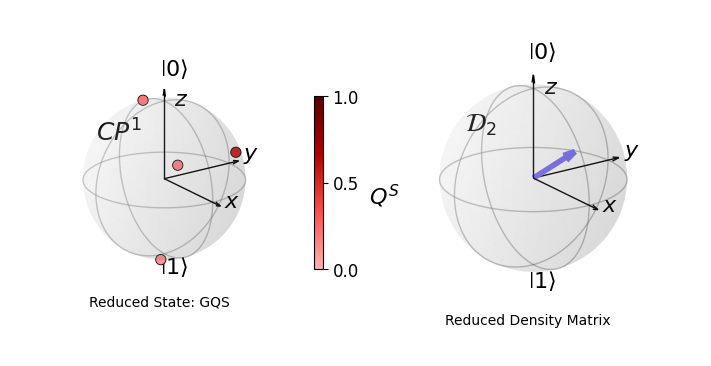

In [30]:
dhilbert = 2
nchain = 3
system_site = 0
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.1082-0.0379j) |000>       + (0.4293-0.2873j) |001>       + (0.3835+0.2758j) |010>       + (-0.1072-0.3287j) |011>      +
(0.2451+0.1743j) |100>       + (-0.0572+0.2390j) |101>      + (-0.3209+0.2415j) |110>      + (0.0460+0.2512j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.4308        0.1003+0.0378j  
|1>         0.1003-0.0378j        0.5692      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 1
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.223-0.078j) |0> + (0.789+0.567j) |1>,0.236000
1,1,|01>,(0.691-0.462j) |0> + (-0.172-0.529j) |1>,0.386000
2,2,|10>,(0.489+0.347j) |0> + (-0.640+0.481j) |1>,0.252000
3,3,|11>,(-0.161+0.674j) |0> + (0.130+0.709j) |1>,0.126000


Reduced States Plot


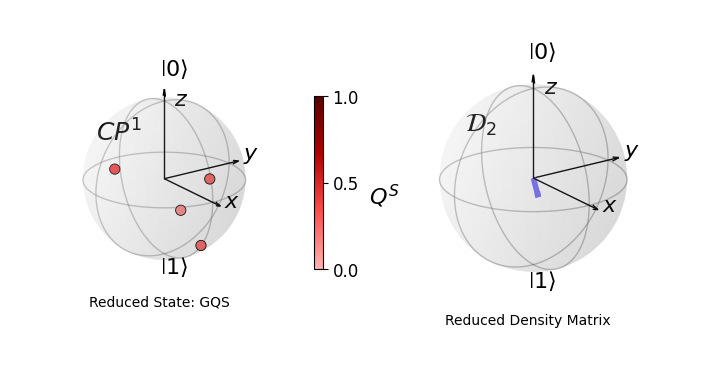

In [31]:
system_site = 1
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.0133+0.2086j) |000>       + (-0.2068-0.3783j) |001>      + (-0.0418+0.1237j) |010>      + (0.0738+0.2121j) |011>       +
(-0.2489+0.2877j) |100>      + (0.1995-0.6084j) |101>       + (0.1080-0.1657j) |110>       + (0.2965+0.1458j) |111>      

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.2446       -0.2753-0.1790j  
|1>        -0.2753+0.1790j        0.7554      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 2
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 4



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.028+0.435j) |0> + (-0.432-0.790j) |1>,0.230000
1,1,|01>,(-0.161+0.476j) |0> + (0.284+0.817j) |1>,0.067000
2,2,|10>,(-0.334+0.386j) |0> + (0.268-0.817j) |1>,0.555000
3,3,|11>,(0.281-0.430j) |0> + (0.770+0.379j) |1>,0.148000


Reduced States Plot


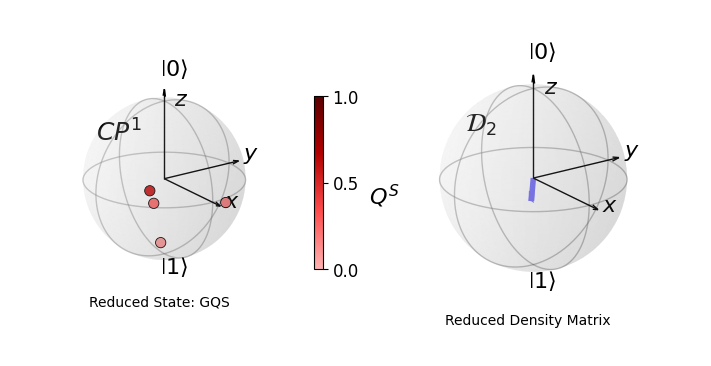

In [32]:
system_site = 2
psi = random_wavefunction(nchain)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)


Global State
(0.0071-0.1993j) |0000>      + (0.3042+0.0951j) |0001>      + (0.1303-0.0992j) |0010>      + (-0.0570-0.0834j) |0011>     +
(-0.0738-0.0632j) |0100>     + (-0.2323+0.0771j) |0101>     + (0.0084-0.2267j) |0110>      + (0.2057-0.2706j) |0111>      +
(0.0481+0.4125j) |1000>      + (-0.0507-0.1185j) |1001>     + (-0.0682-0.0197j) |1010>     + (0.2937+0.1942j) |1011>      +
(-0.2715-0.1789j) |1100>     + (0.1242-0.0241j) |1101>      + (-0.3103-0.0624j) |1110>     + (-0.2123+0.0126j) |1111>    

 Reduced State - Density Matrix
rho_S =

                 |0>               |1>        
|0>             0.4147       -0.1833+0.1483j  
|1>        -0.1833-0.1483j        0.5853      

Trace = 1.0000
Hermitian check = True

 Reduced State - Geometric Quantum State
Geometric Quantum State Q^S
Subsystem site: 0
Subsystem dimension d_S = 2
Number of environment outcomes d_E = 8



,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(0.015-0.433j) |0> + (0.104+0.895j) |1>,0.212000
1,1,|01>,(0.885+0.277j) |0> + (-0.147-0.345j) |1>,0.118000
2,2,|10>,(0.730-0.556j) |0> + (-0.382-0.111j) |1>,0.032000
3,3,|11>,(-0.156-0.228j) |0> + (0.802+0.530j) |1>,0.134000
4,4,|100>,(-0.218-0.186j) |0> + (-0.800-0.527j) |1>,0.115000
5,5,|101>,(-0.843+0.280j) |0> + (0.451-0.087j) |1>,0.076000
6,6,|110>,(0.021-0.582j) |0> + (-0.797-0.160j) |1>,0.152000
7,7,|111>,(0.513-0.675j) |0> + (-0.529+0.032j) |1>,0.161000


Reduced States Plot


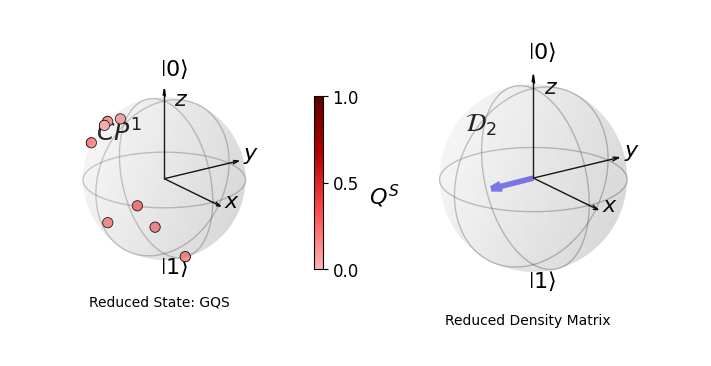

In [27]:
dhilbert = 2
nchain = 4
system_site = 0
psi = random_wavefunction(4)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)

Global State
(-0.2875+0.1024j) |00000>    + (0.1832-0.1643j) |00001>     + (-0.0462-0.1015j) |00010>    + (-0.1728-0.1670j) |00011>    +
(0.2143+0.0530j) |00100>     + (-0.1752+0.0789j) |00101>    + (-0.0013+0.1073j) |00110>    + (-0.0459+0.0479j) |00111>    +
(-0.0477+0.0568j) |01000>    + (0.0922+0.1294j) |01001>     + (-0.0190+0.3066j) |01010>    + (-0.2098+0.0222j) |01011>    +
(-0.0058-0.0219j) |01100>    + (-0.0978+0.2045j) |01101>    + (0.1182-0.1021j) |01110>     + (-0.0093+0.1212j) |01111>    +
(-0.1248-0.0969j) |10000>    + (-0.2453-0.2353j) |10001>    + (-0.1040-0.0666j) |10010>    + (0.1147+0.1457j) |10011>     +
(-0.0513-0.1364j) |10100>    + (-0.0841+0.0733j) |10101>    + (0.0350-0.0323j) |10110>     + (-0.0725+0.1478j) |10111>    +
(0.0230-0.0034j) |11000>     + (0.1157+0.0947j) |11001>     + (0.2204+0.0075j) |11010>     + (0.0794+0.0446j) |11011>     +
(-0.1345+0.0164j) |11100>    + (0.1634-0.1479j) |11101>     + (0.0953-0.0029j) |11110>     + (0.0155-0.0682j) |11111>  

,j,Environment state,|χ_j^S⟩,λ_E[j]
0,0,|00>,(-0.837+0.298j) |0> + (-0.363-0.282j) |1>,0.118000
1,1,|01>,(0.437-0.391j) |0> + (-0.585-0.561j) |1>,0.176000
2,2,|10>,(-0.278-0.610j) |0> + (-0.625-0.400j) |1>,0.028000
3,3,|11>,(-0.569-0.550j) |0> + (0.378+0.480j) |1>,0.092000
4,4,|100>,(0.810+0.201j) |0> + (-0.194-0.516j) |1>,0.070000
5,5,|101>,(-0.789+0.355j) |0> + (-0.379+0.330j) |1>,0.049000
6,6,|110>,(-0.011+0.914j) |0> + (0.298-0.275j) |1>,0.014000
7,7,|111>,(-0.259+0.270j) |0> + (-0.409+0.833j) |1>,0.032000
8,8,|1000>,(-0.614+0.731j) |0> + (0.296-0.044j) |1>,0.006000
9,9,|1001>,(0.422+0.593j) |0> + (0.530+0.434j) |1>,0.048000


Reduced States Plot


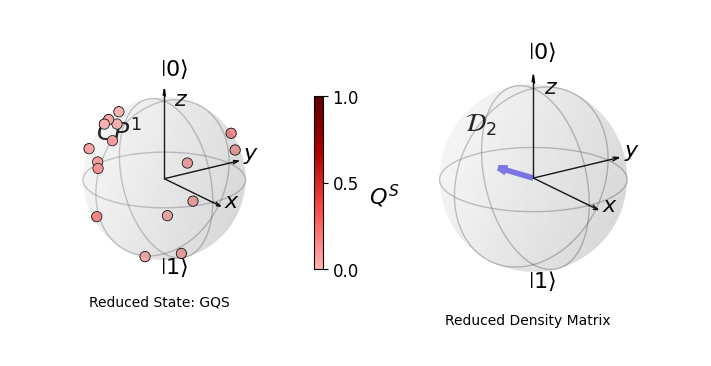

In [28]:
dhilbert = 2
nchain = 5
system_site = 0
psi = random_wavefunction(5)
print("Global State")
print_wavefunction(psi)
print("\n Reduced State - Density Matrix")
rho = rho_single_spin(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_density_matrix(rho)
print("\n Reduced State - Geometric Quantum State")
chi_S, lambda_E = Reduced_state_single_site(d_hilbert=dhilbert,n_chain=nchain,system_site=system_site,Psi_SE=psi)
print_gqs_single_site(chi_S,lambda_E,d_hilbert=dhilbert,n_chain=nchain,system_site=system_site)
print("Reduced States Plot")
_= plot_gqs_and_density_matrix(states=chi_S,weights=lambda_E)